# 10_强化学习-Q-Learning

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文，咱们来今儿来聊聊Q-Learning！！

Q-Learning 相对于其他算法模型，有一点不一样。

Q-Learning 是一种无模型（model-free）的强化学习算法，用于找到一个代理（agent）在给定环境中的最佳策略，使得其累积的奖励最大化。Q-Learning 通过更新一个称为 Q-值（Q-values 或者动作-价值函数）的表来学习每个状态-动作对的价值。

想象你在一个迷宫里走路，每一步都需要决定向哪个方向走，目标是找到出口，并尽可能快速地达到那里。每走一步，你可能会得到一些提示，比如“向前一步有奖赏”或者“走错了路扣分”。

**Q-Learning 就像是记笔记的方法**。你拿着一个笔记本，记录下在每个位置上（状态）采取某个方向（动作）的好坏（Q 值）。一开始你可能什么都不知道，只能凭感觉走。当你走了一段时间后，你的笔记本上逐渐积累了很多信息。

1. **尝试和记录**：一开始，你会随机尝试不同的方向（探索）。每当你采取一个动作（比如向右走）后，你会记录下这一步得到了什么（奖励或者惩罚）。
2. **更新信息**：如果这一步让你接近出口或者得到了奖励，你会更新你的笔记，告诉自己“在这个位置向右走是不错的选择”。如果走错了路，你会记下“这里向右走不好”。
3. **学习和改进**：随着你不断尝试和记录，你的笔记本上的信息越来越多。下一次你回到某个位置时，你会翻开笔记，看看上次哪个方向比较好，然后根据这些信息做出更好的选择（利用）。

通过这种方式，Q-Learning 帮助你逐步找到一条最佳路径，最终你可以在迷宫里游刃有余地找到出口。这就是 Q-Learning 的基本原理：通过不断尝试、记录和更新，找到在不同状态下采取最佳动作的方法。

## 理论基础

Q-Learning 是一种基于价值迭代的强化学习算法，**其核心思想是通过不断更新 Q 值（状态-动作值函数），来逼近最优策略。**

算法基于贝尔曼方程来进行更新。贝尔曼方程定义了状态-动作对的价值 $Q(s, a)$，即在状态 $s$下采取动作 $a$并遵循最优策略所能获得的预期总奖励：


$$
Q(s, a) = \mathbb{E} \left[ r + \gamma \max_{a'} Q(s', a') \mid s, a \right]
$$


其中：

- $s$是当前状态。
- $a$是当前动作。
- $r$是执行动作 $a$后获得的即时奖励。
- $s'$是执行动作 $a$后的下一个状态。
- $\gamma$是折扣因子（0 到 1 之间），表示未来奖励的重要性。
- $a'$是在新状态 $s'$下的动作。

Q-Learning 通过以下更新规则来逼近这个期望值：


$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right)
$$


其中：

- $\alpha$是学习率（0 到 1 之间），控制了每次更新的幅度。

### Q-Learning 的算法流程

Q-Learning 算法的基本流程如下：

1. **初始化**：

   - 初始化 Q 值表 $Q(s, a)$，对于所有状态 $s$和动作 $a$，将 Q 值设为一个初始值（通常设为 0 或一个小的随机数）。
2. **重复以下步骤直到收敛（或者达到最大迭代次数）**：

   1. **初始化当前状态** $s$。
   2. **在当前状态** $s$**中选择动作** $a$：
   
      - 使用 $\epsilon$-贪婪策略（epsilon-greedy policy）：以 $\epsilon$ 的概率随机选择一个动作（探索），以 $1 - \epsilon$ 的概率选择当前 Q 值最大的动作（利用）。
   3. **执行动作** $a$**，观察即时奖励** $r$**和下一个状态** $s'$。
   4. **更新 Q 值**：  
   $Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right)$
   
      - 计算即时奖励 $r$和折扣后的未来奖励 $\gamma \max_{a'} Q(s', a')$ 的和。
      - 使用学习率 $\alpha$ 来调整当前 Q 值 $Q(s, a)$。
   5. **更新当前状态**：
   
      - 将当前状态 $s$更新为下一个状态 $s'$。
3. **输出最优策略**：

   - 在算法收敛后，通过 Q 值表导出最优策略，对于每个状态 $s$，选择 Q 值最大的动作 $a$。

### 伪代码

1. **初始化**：

   - 对所有 $s \in S, a \in A(s)$，初始化 $Q(s, a)$。
   - 设置参数：学习率 $\alpha$，折扣因子 $\gamma$，探索概率 $\epsilon$。
2. **主循环**：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
for each episode do
    初始化状态 s
    while s 不是终止状态 do
        选择动作 a，使用 \epsilon-贪婪策略
        执行动作 a，观察奖励 r 和下一个状态 s'
        更新 Q 值：
            Q(s, a) = Q(s, a) + \alpha [ r + \gamma max_{a'} Q(s', a') - Q(s, a) ]
        s = s'
    end while
end for
```

其中，有几个名词，大家需要注意：

1. **探索与利用（Exploration vs. Exploitation）**：

   - **探索**：尝试新的动作，可能找到更优的策略。
   - **利用**：利用已有的 Q 值选择当前最优的动作。
2. **学习率（Learning Rate,** $\alpha$**）**：

   - 控制每次 Q 值更新的幅度，较高的学习率使得 Q 值更新幅度较大，较低的学习率使得 Q 值更新幅度较小。
3. **折扣因子（Discount Factor,** $\gamma$**）**：

   - 衡量未来奖励的重要性，较高的折扣因子更看重未来的奖励，较低的折扣因子更看重即时的奖励。

通过这些步骤和概念，Q-Learning 算法能够逐渐学习到最优的状态-动作策略，从而在复杂的环境中实现目标。

## 案例

**Q-Learning 案例：简单迷宫**

我们用一个简单的迷宫（Gridworld）环境来展示 Q-Learning 算法。这个迷宫中，智能体需要从起点走到终点，过程中会遇到一些障碍物。我们将展示如何使用 Q-Learning 来学习最佳路径。

**环境描述**

我们首先定义一个迷宫环境，使用一个二维数组表示迷宫的布局。在这个迷宫中：

- **0** 表示可以通过的路径。
- **1** 表示障碍物（墙）。
- 起点为 (0, 0)。
- 终点为 (8, 0)。

迷宫的布局如下：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
maze = [
    [0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0]
]
```

**Q-Learning 算法步骤**

Q-Learning 是一种强化学习算法，通过与环境交互来学习一个策略，该策略告诉智能体在每个状态下应采取的最优行动。以下是Q-Learning的主要步骤：

1. **初始化Q表**：创建一个Q值表，表的每个元素表示一个状态-动作对的值（即智能体在该状态下采取该动作的预期回报）。
2. **观察当前状态**：智能体开始在起始状态。
3. **选择动作**：基于当前状态，使用ε-贪心策略选择一个动作。ε-贪心策略是指智能体以ε的概率选择随机动作，以1-ε的概率选择当前Q值最大的动作。
4. **执行动作**：智能体执行所选动作并观察结果，得到新的状态和奖励。
5. **更新Q值**：根据以下公式更新Q表：  
$Q(s, a) = Q(s, a) + \alpha [r + \gamma \max Q(s', a') - Q(s, a)]$  
其中，$s$ 是当前状态，$a$ 是当前动作，$r$ 是奖励，$s'$ 是新状态，$a'$ 是新动作，$\alpha$ 是学习率，$\gamma$ 是折扣因子。
6. **重复步骤2-5**，直到达到终点或达到最大步数。

代码中，通过 matplotlib 可视化展示 Q-Learning 过程。

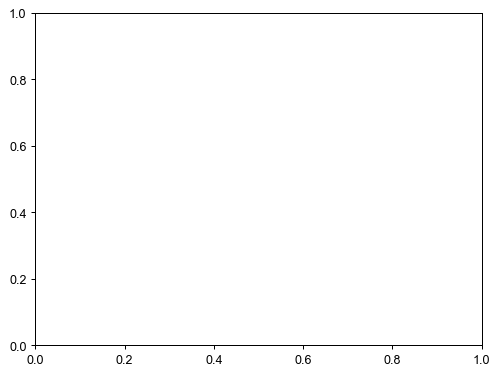

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 迷宫环境
class Maze:
    def __init__(self, maze):
        self.maze = np.array(maze)
        self.n_rows, self.n_cols = self.maze.shape
        self.start = (0, 0)
        self.goal = (8, 0)  # 设置终点位置
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        row, col = self.state
        if action == 0:  # 上
            row = max(0, row - 1)
        elif action == 1:  # 右
            col = min(self.n_cols - 1, col + 1)
        elif action == 2:  # 下
            row = min(self.n_rows - 1, row + 1)
        elif action == 3:  # 左
            col = max(0, col - 1)

        self.state = (row, col)

        if self.state == self.goal:
            reward = 10  # 增大到达终点的奖励
            done = True
        elif self.maze[row, col] == 1:
            reward = -1  # 增大碰壁的惩罚
            done = True
        else:
            reward = -0.1  # 每一步都有微小的惩罚，鼓励智能体尽快到达终点
            done = False

        return self.state, reward, done

# Q-Learning算法
class QLearning:
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.3, episodes=1000):  # 增加epsilon
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.episodes = episodes
        self.q_table = np.zeros((env.n_rows, env.n_cols, 4))  # 4个动作
        self.path_per_episode = []

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(4)  # 随机动作
        else:
            row, col = state
            return np.argmax(self.q_table[row, col])

    def train(self):
        for episode in range(self.episodes):
            state = self.env.reset()
            done = False
            path = [state]
            while not done:
                action = self.choose_action(state)
                next_state, reward, done = self.env.step(action)
                row, col = state
                next_row, next_col = next_state
                self.q_table[row, col, action] += self.alpha * (
                    reward + self.gamma * np.max(self.q_table[next_row, next_col]) - self.q_table[row, col, action]
                )
                state = next_state
                path.append(state)
            self.path_per_episode.append(path)
            # 如果到达了终点，停止训练
            if state == self.env.goal:
                print(f"Reached the goal in episode {episode + 1}")
                break

# 更大的迷宫示例
maze = [
    [0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0]
]

env = Maze(maze)
agent = QLearning(env, episodes=1000)
agent.train()

# 动态展示Q-Learning过程
fig, ax = plt.subplots()

def update(num):
    path = agent.path_per_episode[num]
    
    env_render = env.maze.copy()
    for pos in path:
        env_render[pos[0], pos[1]] = 2

    ax.clear()
    ax.imshow(env_render, cmap='coolwarm', vmin=0, vmax=2)
    ax.set_title(f"Episode: {num + 1}")
    
    # 标注起始位置和目标位置
    ax.text(0, 0, 'S', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    ax.text(0, 8, 'G', ha='center', va='center', color='white', fontsize=12, fontweight='bold')

    # 标注墙体和通道
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            if env.maze[r, c] == 1:
                ax.text(c, r, '█', ha='center', va='center', color='black', fontsize=12)
            elif env.maze[r, c] == 0:
                ax.text(c, r, ' ', ha='center', va='center', fontsize=12)

    return ax

ani = animation.FuncAnimation(fig, update, frames=len(agent.path_per_episode), repeat=False)
plt.show()

动态图的截取，大家可以运行起来\~

![原文参考图，当前结果见代码输出](attachments/img_001.png)

代码中有几点细节，大家需要注意：

1. **Maze类**：定义了迷宫环境。

   - `__init__`: 初始化迷宫、设置起点和终点。
   - `reset`: 重置智能体到起点。
   - `step`: 根据动作更新智能体的位置，返回新的状态、奖励和是否结束。
2. **QLearning类**：实现了Q-Learning算法。

   - `__init__`: 初始化参数，包括学习率、折扣因子、探索率、训练回合数和Q表。
   - `choose_action`: 选择动作，使用ε-贪心策略。
   - `train`: 训练智能体，更新Q表。
3. **主程序**：

   - 定义迷宫。
   - 创建环境和Q-Learning智能体。
   - 训练智能体。
   - 动态展示智能体的训练过程。

整个的代码实现了一个简单的Q-Learning智能体在迷宫环境中的训练和动态展示。通过设置奖励和惩罚机制，智能体逐渐学会避开障碍物并找到到达终点的最优路径。

## 应用场景

Q-Learning 主要适用于以下类型的问题：

1. **离散状态空间和动作空间**：Q-Learning 最适用于具有有限数量状态和动作的环境。
2. **无模型（model-free）问题**：适用于环境模型未知或难以构建的情况。
3. **具有明确目标和奖励的任务**：例如游戏、路径规划等，需要明确的目标和奖励机制。

### 优缺点

**优点**：

1. **无模型依赖**：不需要事先了解环境的转移概率和奖励函数，可以直接通过交互学习。
2. **适应性强**：可以处理各种不同的任务，只要状态和动作是离散的。
3. **理论保证**：在满足一定条件下，Q-Learning 可以保证收敛到最优策略。

**缺点**：

1. **维度灾难**：状态和动作空间较大时，Q 值表会变得非常庞大，导致计算和存储困难。
2. **收敛慢**：特别是在高维状态空间中，收敛速度较慢，需要大量的探索和学习。
3. **探索问题**：需要精细调整探索和利用的平衡，探索过多或过少都会影响学习效果。

### 运用前提条件

1. **离散状态和动作空间**：Q-Learning 假设状态和动作是离散的，对于连续空间需要离散化或采用其他算法（如 DQN）。
2. **明确的奖励机制**：环境需要提供明确的奖励信号，以指导代理的学习过程。
3. **足够的探索**：代理需要足够多的探索来覆盖状态空间，确保 Q 值表的更新充分。

### 实际应用案例

1. **游戏 AI**：在游戏中，Q-Learning 可以用于训练智能体找到最佳策略，例如训练智能体在迷宫中找到最短路径，或在棋盘游戏中采取最佳步骤。
2. **机器人路径规划**：机器人可以使用 Q-Learning 学习在复杂环境中进行路径规划，避开障碍物并找到目标位置。例如，在仓库中自动导引车辆（AGV）的路径优化。
3. **动态资源分配**：在计算资源管理中，Q-Learning 可以用于动态分配资源，例如在数据中心根据需求动态调整服务器的负载分配。
4. **广告投放策略**：在线广告平台可以使用 Q-Learning 优化广告投放策略，最大化点击率或转化率。例如，学习在不同用户特征下展示不同类型的广告。

这些实际应用展示了 Q-Learning 在解决复杂决策问题中的潜力和灵活性，尽管其性能可能受到状态和动作空间大小的限制。